# **Implementing machine learning algorithms for data analytics** 

In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CSIP5203_Task2_Titanic") \
    .getOrCreate()

# 1. Dataset Overview

In [7]:
df = spark.read.csv( "/kaggle/input/datasets/nehavadapally/c2-titanic/TitanicData1.csv",
    header=True,
    inferSchema=True
)

df.show(5)
df.printSchema()

+-----------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+--------+
|PassengerId|Pclass|                Name|   Sex| Age|SibSp|Parch|          Ticket|   Fare|Cabin|Embarked|Survived|
+-----------+------+--------------------+------+----+-----+-----+----------------+-------+-----+--------+--------+
|          1|     3|Braund, Mr. Owen ...|  male|22.0|    1|    0|       A/5 21171|   7.25| NULL|       S|       0|
|          2|     1|Cumings, Mrs. Joh...|female|38.0|    1|    0|        PC 17599|71.2833|  C85|       C|       1|
|          3|     3|Heikkinen, Miss. ...|female|26.0|    0|    0|STON/O2. 3101282|  7.925| NULL|       S|       1|
|          4|     1|Futrelle, Mrs. Ja...|female|35.0|    1|    0|          113803|   53.1| C123|       S|       1|
|          5|     3|Allen, Mr. Willia...|  male|35.0|    0|    0|          373450|   8.05| NULL|       S|       0|
+-----------+------+--------------------+------+----+-----+-----+---------------

The dataset contains a mix of numerical and categorical attributes with missing values. Initial inspection confirms the need for preprocessing before model development.

In [8]:
df.describe().show()

26/02/18 00:47:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+-----------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+-------------------+
|summary|      PassengerId|            Pclass|                Name|   Sex|               Age|             SibSp|              Parch|            Ticket|             Fare|Cabin|Embarked|           Survived|
+-------+-----------------+------------------+--------------------+------+------------------+------------------+-------------------+------------------+-----------------+-----+--------+-------------------+
|  count|              891|               891|                 891|   891|               714|               891|                891|               891|              891|  204|     889|                891|
|   mean|            446.0| 2.308641975308642|                NULL|  NULL| 29.69911764705882|0.5230078563411896|0.38159371492704824|260318.54916792738| 32.2042079685746| NULL|    N

# 2. Data Preprocessing

### 2.1 Missing Value Analysis

In [9]:
df.select([
    (df[c].isNull().cast("int")).alias(c)
    for c in df.columns
]).groupBy().sum().show()

+----------------+-----------+---------+--------+--------+----------+----------+-----------+---------+----------+-------------+-------------+
|sum(PassengerId)|sum(Pclass)|sum(Name)|sum(Sex)|sum(Age)|sum(SibSp)|sum(Parch)|sum(Ticket)|sum(Fare)|sum(Cabin)|sum(Embarked)|sum(Survived)|
+----------------+-----------+---------+--------+--------+----------+----------+-----------+---------+----------+-------------+-------------+
|               0|          0|        0|       0|     177|         0|         0|          0|        0|       687|            2|            0|
+----------------+-----------+---------+--------+--------+----------+----------+-----------+---------+----------+-------------+-------------+



Several attributes, particularly Age and Embarked, contain missing values, which must be addressed to ensure model compatibility and reliability.

### 2.2 Feature Selection

In [10]:
selected_df = df.select(
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
)

selected_df.show(5)


+--------+------+------+----+-----+-----+-------+--------+
|Survived|Pclass|   Sex| Age|SibSp|Parch|   Fare|Embarked|
+--------+------+------+----+-----+-----+-------+--------+
|       0|     3|  male|22.0|    1|    0|   7.25|       S|
|       1|     1|female|38.0|    1|    0|71.2833|       C|
|       1|     3|female|26.0|    0|    0|  7.925|       S|
|       1|     1|female|35.0|    1|    0|   53.1|       S|
|       0|     3|  male|35.0|    0|    0|   8.05|       S|
+--------+------+------+----+-----+-----+-------+--------+
only showing top 5 rows



### 2.3 Missing Values Imputation

In [11]:
from pyspark.sql.functions import col, when

mean_age = selected_df.select("Age").groupBy().mean().first()[0]

clean_df = selected_df \
    .withColumn(
        "Age",
        when(col("Age").isNull(), mean_age).otherwise(col("Age"))
    ) \
    .withColumn(
        "Embarked",
        when(col("Embarked").isNull(), "S").otherwise(col("Embarked"))
    )

clean_df.select([
    (clean_df[c].isNull().cast("int")).alias(c)
    for c in clean_df.columns
]).groupBy().sum().show()

+-------------+-----------+--------+--------+----------+----------+---------+-------------+
|sum(Survived)|sum(Pclass)|sum(Sex)|sum(Age)|sum(SibSp)|sum(Parch)|sum(Fare)|sum(Embarked)|
+-------------+-----------+--------+--------+----------+----------+---------+-------------+
|            0|          0|       0|       0|         0|         0|        0|            0|
+-------------+-----------+--------+--------+----------+----------+---------+-------------+



### 2.4 Outlier Analysis

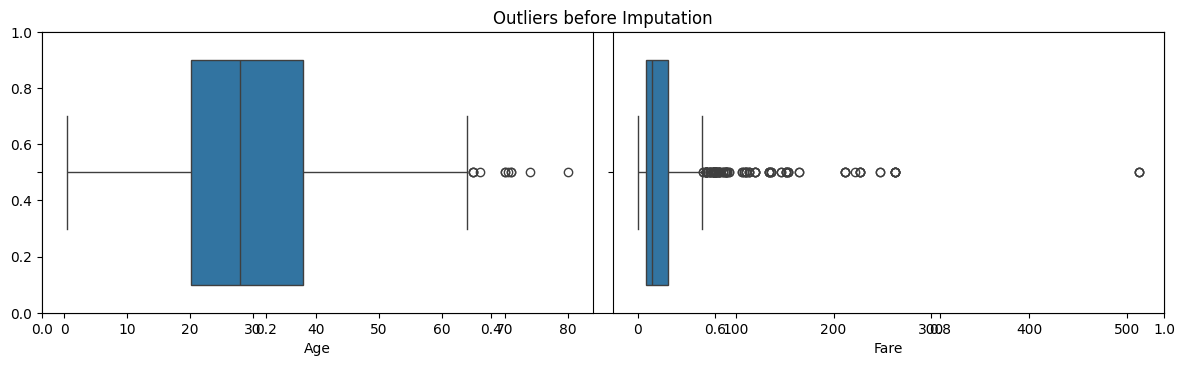

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert required columns to Pandas for plotting
pdf_outliers = df.select("Age", "Fare").toPandas()

plt.figure(figsize=(12, 4))
plt.title("Outliers before Imputation")
# Age boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=pdf_outliers["Age"])
plt.xlabel("Age")

# Fare boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=pdf_outliers["Fare"])
plt.xlabel("Fare")

plt.tight_layout()
plt.show()


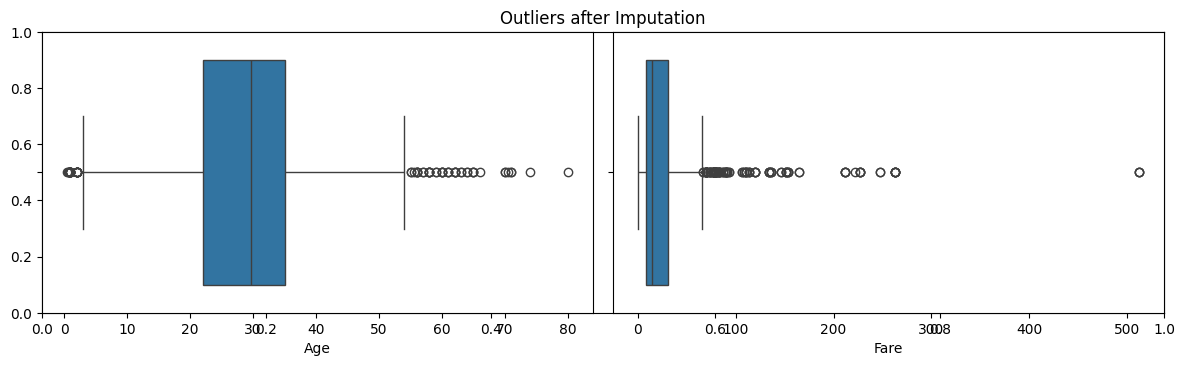

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert required columns to Pandas for plotting
pdf_outliers = clean_df.select("Age", "Fare").toPandas()

plt.figure(figsize=(12, 4))
plt.title("Outliers after Imputation")
# Age boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x=pdf_outliers["Age"])
plt.xlabel("Age")

# Fare boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=pdf_outliers["Fare"])
plt.xlabel("Fare")

plt.tight_layout()
plt.show()

### 2.5 Class Distribution Analysis

In [14]:
clean_df.groupBy("Survived").count().show()
clean_df.groupBy("Survived","Pclass").count().show()

+--------+-----+
|Survived|count|
+--------+-----+
|       1|  342|
|       0|  549|
+--------+-----+

+--------+------+-----+
|Survived|Pclass|count|
+--------+------+-----+
|       1|     2|   87|
|       1|     1|  136|
|       1|     3|  119|
|       0|     1|   80|
|       0|     2|   97|
|       0|     3|  372|
+--------+------+-----+



The dataset exhibits class imbalance, with non-survivors forming the majority class. This motivates the use of multiple evaluation metrics beyond accuracy.

# 3. Data Visualization and Anlaysis
### 3.1 Survival by Gender

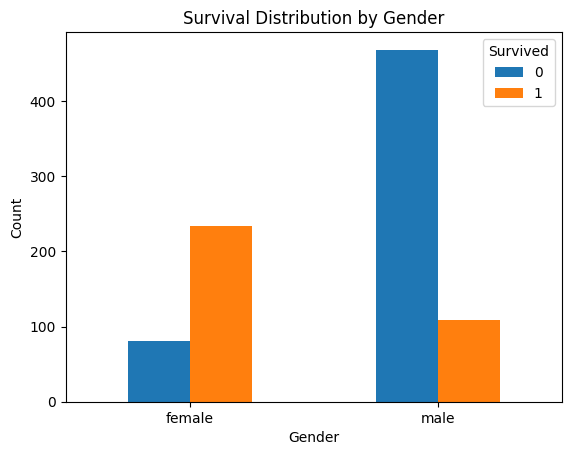

In [15]:
import matplotlib.pyplot as plt

pdf = clean_df.select("Sex", "Survived").toPandas()
pdf.groupby(["Sex", "Survived"]).size().unstack().plot(kind="bar")
plt.title("Survival Distribution by Gender")
plt.xticks(rotation=0)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Female passengers show significantly higher survival rates, indicating gender as a key predictive feature.

### 3.2 Survival by Passenger Class

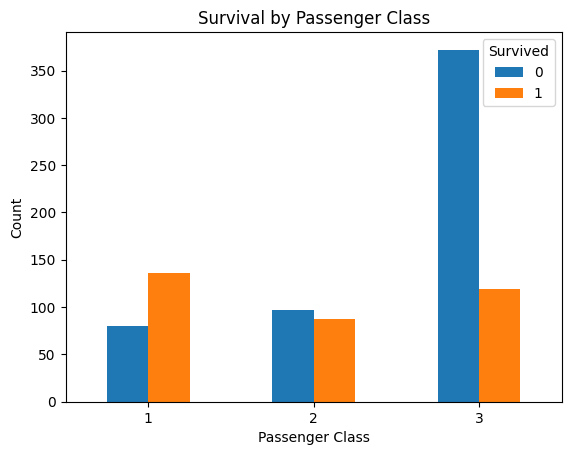

In [16]:
pdf_class = clean_df.select("Pclass", "Survived").toPandas()

pdf_class.groupby(["Pclass", "Survived"]).size().unstack().plot(kind="bar")
plt.title("Survival by Passenger Class")
plt.xticks(rotation=0)
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

Higher-class passengers(1) demonstrate improved survival outcomes, highlighting socio-economic influence on survival probability.

# 4. Feature Engineering
### 4.1 Encoding categorical variables

In [17]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder

sex_indexer = StringIndexer(
    inputCol="Sex",
    outputCol="SexIndex",
    handleInvalid="keep"
)

embarked_indexer = StringIndexer(
    inputCol="Embarked",
    outputCol="EmbarkedIndex",
    handleInvalid="keep"
)

encoder = OneHotEncoder(
    inputCols=["SexIndex", "EmbarkedIndex"],
    outputCols=["SexVec", "EmbarkedVec"]
)

One-hot encoding avoids imposing ordinal relationships on categorical features, ensuring compatibility with linear classifiers.

### 4.2 Feature Vector Construction and Normalisation

In [18]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "SexVec",
        "EmbarkedVec"
    ],
    outputCol="features"
)

In [19]:
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withMean=True,
    withStd=True
)

Standardisation is applied for Logistic Regression to prevent dominance of high-magnitude features.

# 5. Classification Models
### 5.1 Train - Test Split Strategy

In [20]:
train_df, test_df = clean_df.randomSplit([0.7, 0.3], seed=42)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 659
Testing records: 232


A fixed random seed was used to ensure reproducibility of the train–test split and consistency of experimental results across runs.

In [21]:
print("Survived Count in Training Data")
train_df.groupBy("Survived").count().show()
print("Survived Count in Testing Data")
test_df.groupBy("Survived").count().show()

Survived Count in Training Data
+--------+-----+
|Survived|count|
+--------+-----+
|       1|  248|
|       0|  411|
+--------+-----+

Survived Count in Testing Data
+--------+-----+
|Survived|count|
+--------+-----+
|       1|   94|
|       0|  138|
+--------+-----+



### 5.2 Logistic Regression Model

In [22]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

lr = LogisticRegression(
    labelCol="Survived",
    featuresCol="scaledFeatures"
)

lr_pipeline = Pipeline(stages=[
    sex_indexer,
    embarked_indexer,
    encoder,
    assembler,
    scaler,
    lr
])

lr_model = lr_pipeline.fit(train_df)
lr_predictions = lr_model.transform(test_df)

### 5.3 Naive Bayes Model

In [23]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(
    labelCol="Survived",
    featuresCol="features"
)

nb_pipeline = Pipeline(stages=[
    sex_indexer,
    embarked_indexer,
    encoder,
    assembler,
    nb
])

nb_model = nb_pipeline.fit(train_df)
nb_predictions = nb_model.transform(test_df)

# 6. Result Analysis
### 6.1 Model Performance Metrics

In [24]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator(
    labelCol="Survived",
    predictionCol="prediction",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)
nb_accuracy = evaluator.evaluate(nb_predictions)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Naive Bayes Accuracy:", nb_accuracy)

Logistic Regression Accuracy: 0.7931034482758621
Naive Bayes Accuracy: 0.6810344827586207


### 6.2 Confusion Matrix Anlaysis

In [25]:
print("Confusion Matrix – Logistic Regression")
lr_predictions.groupBy("Survived", "prediction") \
    .count() \
    .orderBy("Survived", "prediction") \
    .show()

print("Confusion Matrix – Naive Bayes")
nb_predictions.groupBy("Survived", "prediction") \
    .count() \
    .orderBy("Survived", "prediction") \
    .show()

Confusion Matrix – Logistic Regression
+--------+----------+-----+
|Survived|prediction|count|
+--------+----------+-----+
|       0|       0.0|  112|
|       0|       1.0|   26|
|       1|       0.0|   22|
|       1|       1.0|   72|
+--------+----------+-----+

Confusion Matrix – Naive Bayes
+--------+----------+-----+
|Survived|prediction|count|
+--------+----------+-----+
|       0|       0.0|  115|
|       0|       1.0|   23|
|       1|       0.0|   51|
|       1|       1.0|   43|
+--------+----------+-----+



The confusion matrices show that Logistic Regression achieves better class separation, with fewer false negatives compared to Naive Bayes. 

This is reflected in higher overall accuracy (0.79 vs 0.68), indicating more reliable survival prediction.

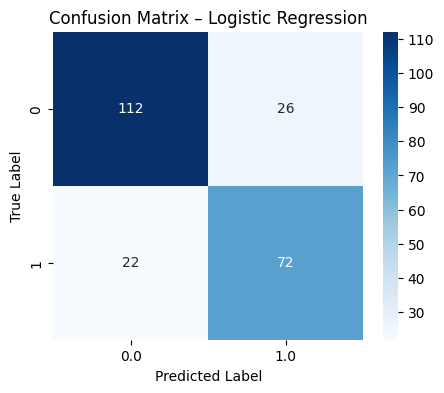

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert confusion matrix to Pandas
cm_lr = (
    lr_predictions
    .groupBy("Survived", "prediction")
    .count()
    .toPandas()
)

# Pivot to matrix form
cm_lr_pivot = cm_lr.pivot(
    index="Survived",
    columns="prediction",
    values="count"
).fillna(0)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr_pivot,
    annot=True,      # show numbers
    fmt="d",         # integer format
    cmap="Blues",
    cbar=True       
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

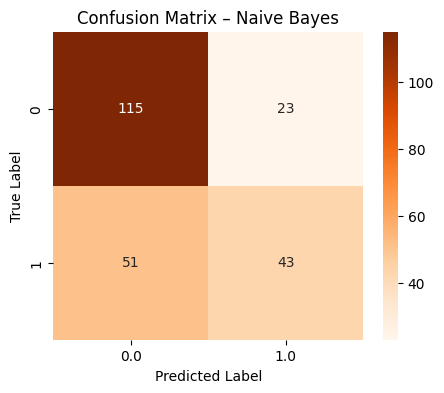

In [27]:
cm_nb = (
    nb_predictions
    .groupBy("Survived", "prediction")
    .count()
    .toPandas()
)

cm_nb_pivot = cm_nb.pivot(
    index="Survived",
    columns="prediction",
    values="count"
).fillna(0)


plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_nb_pivot,
    annot=True,      # show numbers
    fmt="d",         # integer format
    cmap="Oranges",
    cbar=True       
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

### 6.3 Comparative Model Evaluation

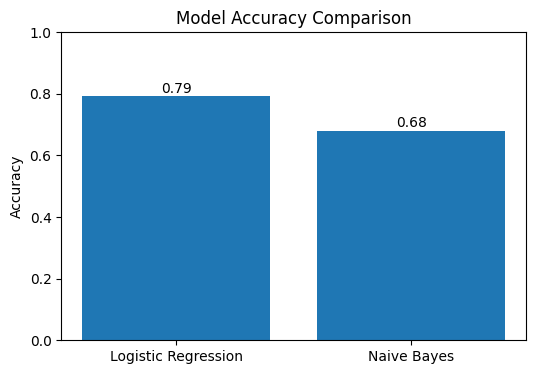

In [28]:
models = ["Logistic Regression", "Naive Bayes"]
accuracies = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha="center")

plt.show()

In [29]:
metrics = ["precisionByLabel", "recallByLabel", "f1"]

print("Logistic Regression Metrics")
for metric in metrics:
    evaluator.setMetricName(metric)
    print(f"{metric}: {evaluator.evaluate(lr_predictions):.4f}")

print("\nNaive Bayes Metrics")
for metric in metrics:
    evaluator.setMetricName(metric)
    print(f"{metric}: {evaluator.evaluate(nb_predictions):.4f}")

Logistic Regression Metrics
precisionByLabel: 0.8358
recallByLabel: 0.8116
f1: 0.7937

Naive Bayes Metrics
precisionByLabel: 0.6928
recallByLabel: 0.8333
f1: 0.6678


ROC-AUC: 0.849290780141844


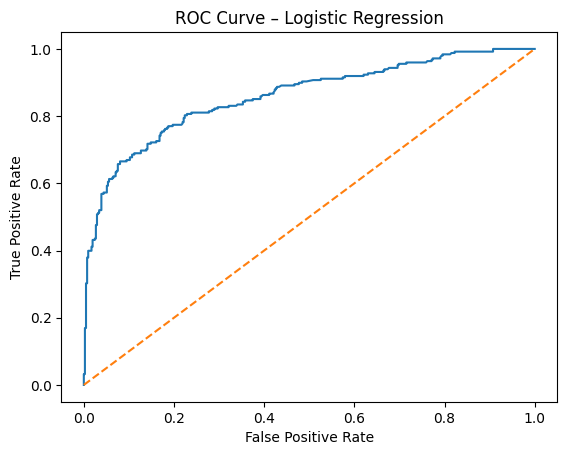

In [30]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

roc_eval = BinaryClassificationEvaluator(
    labelCol="Survived",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

roc_auc = roc_eval.evaluate(lr_predictions)
print("ROC-AUC:", roc_auc)

roc_df = lr_model.stages[-1].summary.roc.toPandas()

plt.plot(roc_df['FPR'], roc_df['TPR'])
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Logistic Regression")
plt.show()


In [31]:
lr_predictions \
    .filter(col("Survived") != col("prediction")) \
    .select("Survived", "prediction", "scaledFeatures") \
    .show(10)

nb_predictions \
    .filter(col("Survived") != col("prediction")) \
    .select("Survived", "prediction", "features") \
    .show(10)

+--------+----------+--------------------+
|Survived|prediction|      scaledFeatures|
+--------+----------+--------------------+
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
|       0|       1.0|[-1.6667172731712...|
+--------+----------+--------------------+
only showing top 10 rows

+--------+----------+--------------------+
|Survived|prediction|            features|
+--------+----------+--------------------+
|       0|       1.0|[1.0,21.0,0.0,1.0...|
|       0|       1.0|(10,[0,1,4,5,8],[...|
|       0|       1.0|[1.0,24.0,0.0,1.0...|
|       0|       1.0|[1.0,29.0,1.0,0.0...|
|       0|       1.0|(10,[0,1,4,5,7],[...|
|       0|       1.0|(10,[0,

Logistic Regression consistently outperforms Naive Bayes, achieving higher accuracy (0.79 vs 0.68) and better class separation. 

This is further supported by a strong ROC–AUC score of 0.85, indicating reliable discrimination across thresholds.

In contrast, Naive Bayes shows weaker sensitivity to the minority class, leading to higher misclassification of survivors.